<a href="https://colab.research.google.com/github/jafeerahere/231A022_NLP-Experiments/blob/main/AIDS_NLP_Experiments2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ansari Jafeera/231A022**


In [7]:
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
import random
import string
import pandas as pd

nltk.download('twitter_samples')

all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

positive_tweets=pd.DataFrame(all_positive_tweets,columns=["Tweets"])
negative_tweets=pd.DataFrame(all_negative_tweets,columns=["Tweets"])
positive_tweets["Sentiments"]="positive"
negative_tweets["Sentiments"]="negative"

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


In [8]:
nltk.download('twitter_samples')


[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

In [9]:
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

In [10]:
print(f'Number of positive tweets: {len(all_positive_tweets)}')
print(f'Number of negative tweets: {len(all_negative_tweets)}')

Number of positive tweets: 5000
Number of negative tweets: 5000


In [11]:
from nltk.corpus import twitter_samples

In [12]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [13]:
pd.DataFrame(twitter_samples.fileids())

,0
0,negative_tweets.json
1,positive_tweets.json
2,tweets.20150430-223406.json


In [14]:
positive_tweets.head()

,Tweets,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


In [15]:
positive_tweets["Sentiments"]='positive'
positive_tweets

,Tweets,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive
...,...,...
4995,"@chriswiggin3 Chris, that's great to hear :) D...",positive
4996,@RachelLiskeard Thanks for the shout-out :) It...,positive
4997,@side556 Hey! :) Long time no talk...,positive
4998,@staybubbly69 as Matt would say. WELCOME TO AD...,positive


In [16]:
negative_tweets["Sentiments"]='negative'
negative_tweets

,Tweets,Sentiments
0,hopeless for tmr :(,negative
1,Everything in the kids section of IKEA is so c...,negative
2,@Hegelbon That heart sliding into the waste ba...,negative
3,"“@ketchBurning: I hate Japanese call him ""bani...",negative
4,"Dang starting next week I have ""work"" :(",negative
...,...,...
4995,I wanna change my avi but uSanele :(,negative
4996,MY PUPPY BROKE HER FOOT :(,negative
4997,where's all the jaebum baby pictures :((,negative
4998,But but Mr Ahmad Maslan cooks too :( https://t...,negative


In [17]:
all_tweets = pd.concat([positive_tweets, negative_tweets], ignore_index=True)

display(all_tweets.head())
display(all_tweets.tail())


,Tweets,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


,Tweets,Sentiments
9995,I wanna change my avi but uSanele :(,negative
9996,MY PUPPY BROKE HER FOOT :(,negative
9997,where's all the jaebum baby pictures :((,negative
9998,But but Mr Ahmad Maslan cooks too :( https://t...,negative
9999,@eawoman As a Hull supporter I am expecting a ...,negative


In [18]:
all_tweets_shuffled = all_tweets.sample(frac=1).reset_index(drop=True)
all_tweets_shuffled

,Tweets,Sentiments
0,Morning all! Up and at 'em :),positive
1,justinbieber can u pls follow me on &gt;daiane...,negative
2,@MandaScapinello oh yeah?? I am definitely goi...,positive
3,real talk does my account match or no? :(,negative
4,@madziucha_5 yes he is :),positive
...,...,...
9995,@sadcuddleashton me too but dont get ur hopes ...,negative
9996,#FF to @TashaFairybro @dorkfaceblog @BeckyBedb...,positive
9997,Sense Of Awe :) http://t.co/JTjojcdhWG via @Di...,positive
9998,@Uber no ice cream for me :-( #getthescoop htt...,negative


In [19]:
tweet1=all_tweets_shuffled.iloc[620]
(tweet1["Tweets"])

'My cat loves to snuggle up right by my face &amp; I love it but can never breathe :('

In [20]:
y_positive=(all_tweets_shuffled["Sentiments"]== "positive").sum()

In [21]:
y_negative=(all_tweets_shuffled["Sentiments"]== "negative").sum()

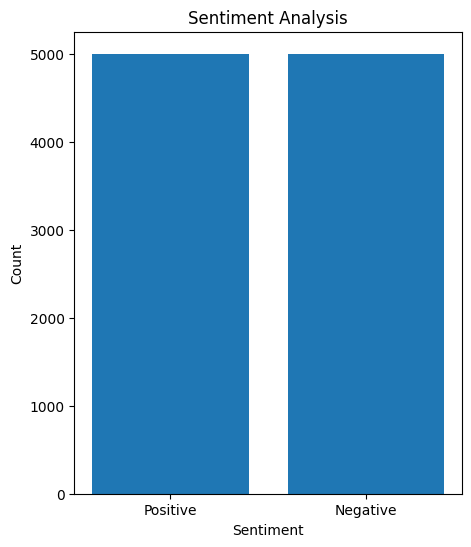

In [22]:
fig = plt.figure(figsize=(5, 6))
labels='Positive','Negative'
sizes=[y_positive,y_negative]
plt.bar(labels,sizes,)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Analysis')
plt.show()

In [23]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [24]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [25]:
tweet2 = re.sub(r'RT[\s]+',' ',tweet1["Tweets"])
tweet2 = re.sub(r'https?://[^\s\n\r]+',' ',tweet2)
tweet2 = re.sub(r'#',' ',tweet2)
tweet2 = re.sub(r'@',' ',tweet2)
tweet2 = re.sub(r'[:)|(:)]',' ',tweet2)
print(tweet1)
print("Cleaned tweet:\n")
print( tweet2)


Tweets        My cat loves to snuggle up right by my face &a...
Sentiments                                             negative
Name: 620, dtype: object
Cleaned tweet:

My cat loves to snuggle up right by my face &amp; I love it but can never breathe   


In [26]:
tokenizer = TweetTokenizer(preserve_case=False,strip_handles=True,reduce_len=True)

tweet_tokens = tokenizer.tokenize(tweet2)
print()
print("Tokenized string:" )
print(tweet_tokens)


Tokenized string:
['my', 'cat', 'loves', 'to', 'snuggle', 'up', 'right', 'by', 'my', 'face', '&', 'i', 'love', 'it', 'but', 'can', 'never', 'breathe']


In [27]:
stopwords_english = stopwords.words('english')

print("Stop words\n")
print(stopwords_english)

print("\nPunctuation\n")
print(string.punctuation)

Stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

In [28]:
print(tweet_tokens)
print()
tweets_clean = []
for word in tweet_tokens:
    if (word not in stopwords_english and word not in string.punctuation):
        tweets_clean.append(word)
print("Removed stop words and punctuation:")
print(tweets_clean)

['my', 'cat', 'loves', 'to', 'snuggle', 'up', 'right', 'by', 'my', 'face', '&', 'i', 'love', 'it', 'but', 'can', 'never', 'breathe']

Removed stop words and punctuation:
['cat', 'loves', 'snuggle', 'right', 'face', 'love', 'never', 'breathe']


In [29]:
def process_tweet(tweet):
  tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,reduce_len=True)

  tweet = re.sub(r'^RT[\s]+', '', tweet)
  tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet)
  tweet = re.sub(r'#', '', tweet)
  tweet = re.sub(r'@', '', tweet)
  tweet = re.sub(r'[:)|(:)]', '', tweet)
  tweet_tokens = tokenizer.tokenize(tweet)
  stopwords_english = stopwords.words('english')

  tweets_clean = []
  for word in tweet_tokens:
      if (word not in stopwords_english and word not in string.punctuation):
          tweets_clean.append(word)
  return tweets_clean

In [30]:
tweet1=all_tweets_shuffled.iloc[620]
print(tweet1["Tweets"])
print()
print(process_tweet(tweet1["Tweets"]))

My cat loves to snuggle up right by my face &amp; I love it but can never breathe :(

['cat', 'loves', 'snuggle', 'right', 'face', 'love', 'never', 'breathe']


In [31]:
processed_tweets=all_tweets['Tweets'].apply(process_tweet)
all_tweets['Tweets_processed']=processed_tweets
pd.set_option('display.max_colwidth',None)
all_tweets

,Tweets,Sentiments,Tweets_processed
0,#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :),positive,"[followfriday, france_inte, pkuchly, 57, milipol_paris, top, engaged, members, community, week]"
1,@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!,positive,"[lamb, 2ja, hey, james, odd, please, call, contact, centre, 02392441234, able, assist, many, thanks]"
2,@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!,positive,"[despiteofficial, listen, last, night, bleed, amazing, track, scotland]"
3,@97sides CONGRATS :),positive,"[97sides, congrats]"
4,yeaaaah yippppy!!! my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days,positive,"[yeaaah, yipppy, accnt, verified, rqst, succeed, got, blue, tick, mark, fb, profile, 15, days]"
...,...,...,...
9995,I wanna change my avi but uSanele :(,negative,"[wanna, change, avi, usanele]"
9996,MY PUPPY BROKE HER FOOT :(,negative,"[puppy, broke, foot]"
9997,where's all the jaebum baby pictures :((,negative,"[where's, jaebum, baby, pictures]"
9998,But but Mr Ahmad Maslan cooks too :( https://t.co/ArCiD31Zv6,negative,"[mr, ahmad, maslan, cooks]"
